# *♥*♡∞:｡.｡♥*♡∞:｡.｡ deflection angle comparisons yay *♥*♡∞:｡.｡♥*♡∞:｡.｡

In [1]:
import numpy as np
from astropy import units as u
from astropy import constants as const
import matplotlib.pyplot as plt
from scipy.special import ellipkinc #first incomplete kind
from scipy.special import ellipeinc #second incomplete kind
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
#rc('text', usetex=True)

In [10]:
# from /Users/valeriauhu/.local/share/uv/tools/manim/ import manim

import os
import sys
module_path = os.path.abspath(os.path.join('/Users/valeriauhu/.local/share/uv/tools/manim'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from module_path import manim

ModuleNotFoundError: No module named 'module_path'

### Bozza method

In [2]:
#Bozza

def thetabozza(b): #input: impact parameter -> b = theta * D_ol
    A = np.log(((2*b)/(3*np.sqrt(3))) - 1) 
    B = np.log(216*(7 - 4*np.sqrt(3))) 
    print('A = ', A, ', and B = ', B)
    thetab = -A + B - np.pi
    return thetab

In [3]:
#arc sec to rad converter
def asec2rad(arcsec): #arc seconds to radians
    rads = arcsec*(np.pi/648000)
    return rads

In [4]:
def d2rs(d,M): #distance (in meters) to one over Schwarzschild radius (1/r_s)
    M_bhmw = (M*u.M_sun).to(u.kg) #mass of MW BH from Msun to kg
    dinrs = d*(((const.c)**2)/(2*(const.G)*(M_bhmw))) # D_ol * c^2/GM -> r_s = 2GM/c^2
    return dinrs #distance in terms of r_s

In [5]:
#From Bozza: theta_inf = 16.87 microarcsec, M_BHMW = 2.8e6 Msun, D_OL = 8.5 kpc

#distance from object to lens converted from parsecs to meters from bozza ex
dol = (8.5e3*u.pc).to(u.meter) 
dolrs = d2rs(dol,2.8e6) #converting distance from meters to r_s using function
# dolrs

#calculating impact parameter using b = theta * D_ol
b_b = (asec2rad(16.898e-6))*(dolrs)
b_b

<Quantity 2.59849203>

In [6]:
thetabozza(b_b) #calculating deflection angle using b from Bozza example numbers into function                                                                                                                                                                                                                                                       

A =  -8.740043266595782 , and B =  2.741362613834537


<Quantity 8.33981323>

### Holz & Wheeler method

In [7]:
# Holz and Wheeler method

def thetaHW(M,b): #inputs: mass of BH and impact parameter 
    A = b/M - 3*np.sqrt(3)
    B = 3.4823
    thetaHW = -1*np.log(A/B)
    print('A = ', A, ', and B = ', B)
    #A = 3*(np.sqrt(3))*(3.4823)*(M**2)
    #thetaHW = np.log(A/b)
    return thetaHW

In [8]:
#taking the same numbers from Bozza

M_bhmw = 2.8e6*(u.M_sun).to(u.kg) #mass from Msun to kg
print(M_bhmw)
#M_bhgeo = (M_bhmw*u.meter)/(1.35e27) #switch from kg to geometric units M [kg] -> M [m] by M * c^2/G
M_bhgeo = (M_bhmw*u.kg)*(const.G/const.c**2)
print(M_bhgeo)

b_hw = (asec2rad(16.898e-6))*(dol)
print(b_hw)

thetaHW(M_bhgeo,b_hw) #obtaining deflection angle using HW method through our function

5.567547637954543e+36
4134550106.54035 m
21487190962.253098 m
A =  0.0008316284149163522 , and B =  3.4823


<Quantity 8.33981783>

In [5]:
print 2

SyntaxError: Missing parentheses in call to 'print'. Did you mean print(2)? (3297204859.py, line 1)

In [9]:
# thetas_infs = np.linspace()
# d_ols = np.linspace()

# bbs = []
# defangsb = []

# #bozza
# for i in range(len(d_ols)):
#     #Mbh = 
#     #distance from object to lens converted from parsecs to meters from bozza ex
#     dol = (d_ol[i]*u.pc).to(u.meter) 
#     dolrs = d2rs(dol,Mbh) #converting distance from meters to r_s using function
#     #calculating impact parameter using b = theta * D_ol
#     b_b = (asec2rad(theta_infs[i]))*(dolrs)
#     bbs.append(b_b)
#     defangs = thetabozza(b_b)
#     defangsb.append(defangs)

## magnification of higher order images via bozza (2010)

In [10]:
def mag_2(M,r_S,D_OS,r_O): #mass of BH, radial position of source, distance between source/observer, radial position of observer
    delphi = np.linspace(0,np.pi,num=300)
    abar = 1
    num = (3+np.sqrt(3))*(np.sqrt(3+18*(M/r_S)))
    print('num = ',num)
    den = 36*np.sqrt(6)
    print('den = ',den)
    bbar = -2*np.log(num/den)
    print('bbar = ',bbar)
    expart = (bbar - delphi)/abar
    print('expart = ',expart)
    ubar = 3*(np.sqrt(3))*M
    print('ubar = ',ubar)
    thetabar = ubar/r_O #shadow border
    print('thetabar = ',thetabar)
    mag_2 = ((D_OS/r_S)**2)*(thetabar**2/(abar*np.sin(delphi)))*np.exp(expart) #magnification of higher order image -> n=0
    return mag_2

In [11]:
# mag_2(5,200,8.5e3,500) #random test

## magnification (gain) of images via ohanian (1987)

In [12]:
beta2 = np.linspace(0,1/3,num=3000) #eric mentioned these are usual numbers

root = np.sqrt(1 + 4*beta2*(1-3*beta2))

#lambda derivative
dlamdb = (beta2*np.sqrt((beta2**2)*(1-2*beta2))*(1+4*beta2*(-2+3*beta2)))/((2*np.sqrt(2))*(-1 + 3*beta2)*((1 + 4*beta2*(1 - 3*beta2))**(3/4)))
#print(dlamdb)

#theta derivative
num1 = -3 + 36*beta2**2 + 5*root - 6*beta2*(2 + root)
den1 = (1 - 3*beta2)**2
num2 = (np.sqrt(3/2)*beta2*np.sqrt((beta2**2)*(1 - 2*beta2)))*np.sqrt(num1/den1)
den2 = (-1 + 3*beta2)*(1 + 6*beta2)
dthetdb = num2/den2
#print(dthetdb)

# alpha derivative
num1 = (((1-2*beta2)**2)*(beta2**3)*(0.176777 - 0.176777*root + beta2*(2.12132 - 6.36396*beta2 + 1.06066 *root)))
den1 = (((-1 + 3*beta2)*root*np.sqrt(beta2**2 - 2*beta2**3)*(root*(1 - 6*beta2 + root)))**1/2)*(np.sqrt(1 - 0.0078125*root*(1 - 6*beta2 + root)))
dalphdb = num1/den1
#print(dalphdb)

/var/folders/3w/vvnsh1vj0cj52s20fz6bc2g00000gn/T/ipykernel_39709/2777477064.py:6: RuntimeWarning: divide by zero encountered in true_divide
  dlamdb = (beta2*np.sqrt((beta2**2)*(1-2*beta2))*(1+4*beta2*(-2+3*beta2)))/((2*np.sqrt(2))*(-1 + 3*beta2)*((1 + 4*beta2*(1 - 3*beta2))**(3/4)))
/var/folders/3w/vvnsh1vj0cj52s20fz6bc2g00000gn/T/ipykernel_39709/2777477064.py:12: RuntimeWarning: invalid value encountered in true_divide
  num2 = (np.sqrt(3/2)*beta2*np.sqrt((beta2**2)*(1 - 2*beta2)))*np.sqrt(num1/den1)
/var/folders/3w/vvnsh1vj0cj52s20fz6bc2g00000gn/T/ipykernel_39709/2777477064.py:20: RuntimeWarning: divide by zero encountered in true_divide
  dalphdb = num1/den1
/var/folders/3w/vvnsh1vj0cj52s20fz6bc2g00000gn/T/ipykernel_39709/2777477064.py:20: RuntimeWarning: invalid value encountered in true_divide
  dalphdb = num1/den1


In [13]:
def Ohamag(M,D): #make sure right units for G,c,M,D
    #u = (3*const.G*M)/(const.c**2) #r = 3GM/c^2 and u = 1/r right ?
    #num = 2*(u**3) - u**2
    D = D*u.m
    M = M*u.kg
    beta2 = np.linspace(0,1/3,num=3000) #eric mentioned these are usual numbers
    lambd = 0.5*((0.5-beta2)*(0.5+3*beta2))**(1/4)
    cos2theta = ((0.5 - 3*beta2 + 4 * lambd**2)/(-0.5 + 3*beta2 + 4 * lambd**2))*((-0.5 + beta2 + 4 * lambd**2)/(0.5 - beta2 + 4 * lambd**2))
    sin2theta = 1-cos2theta
    theta = np.arccos(np.sqrt(cos2theta)) 
    cos2alpha = (0.5 - 3*beta2 + 4 * lambd**2)/(8 * lambd**2)
    m = 1 - cos2alpha # m = sin^2(alpha)
    alpha = np.arccos(np.sqrt(cos2alpha))
    phi = (np.sqrt(2)/lambd)*ellipkinc(theta,m) #inputs = phi m out
    b = ((beta2**2)*(1-2*beta2))**-0.5
    Ffunc = ellipkinc(theta, m)
    Efunc = ellipeinc(theta,m)
#     dldb = dlambda/db
#     dtdb = dtheta/db
#     dadb = dalpha/db - these derivatives are calculated above
    dpdb1 = ((-1*np.sqrt(2))/(lambd**2))*(ellipkinc(theta,m))*dlamdb
    dpdb2 = ((np.sqrt(2))*(dthetdb))/(lambd*((1 - m*sin2theta)**0.5))
    dpdb3 = (np.sqrt(2)*(np.tan(alpha))*(dalphdb))*(Ffunc + ((Efunc-Ffunc)/m) - (np.sqrt(cos2theta)*np.sqrt(sin2theta))/((1-m*sin2theta)**0.5))
    dpdb = dpdb1 + dpdb2 + dpdb3
    gain = ((const.G*M)**2/((const.c**2)*D)**2)*(b/(abs(np.sin(phi - np.pi)*(dpdb))))
    return gain, b, phi

In [14]:
gaintest, btest, phitest = Ohamag(1,(const.G/const.c**2)*(u.kg/u.m))
gaintest

/var/folders/3w/vvnsh1vj0cj52s20fz6bc2g00000gn/T/ipykernel_39709/3083761559.py:15: RuntimeWarning: divide by zero encountered in power
  b = ((beta2**2)*(1-2*beta2))**-0.5


<Quantity [           nan, 4.32463897e+14, 2.70208628e+13, ...,
           2.08422571e-05, 7.38353182e-06,            nan]>

(0.0, 14.0)

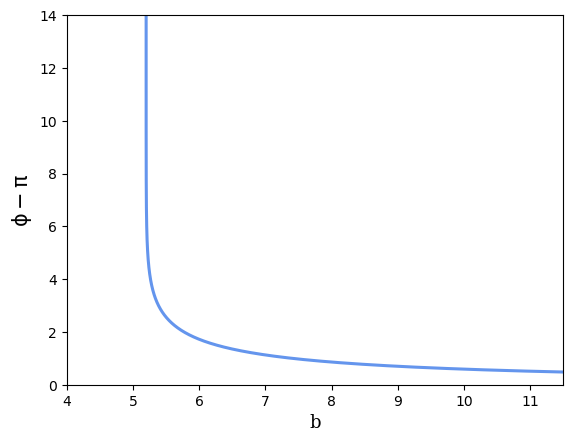

In [45]:
#btest
#beta2

plt.plot(btest,phitest-np.pi, color='cornflowerblue',linewidth=2.2)
plt.ylabel(r'$\rm \phi - \pi$',fontsize=15)
plt.xlabel('b',fontsize=13,fontproperties=font)
plt.xlim(4,11.5)
plt.ylim(0,14)

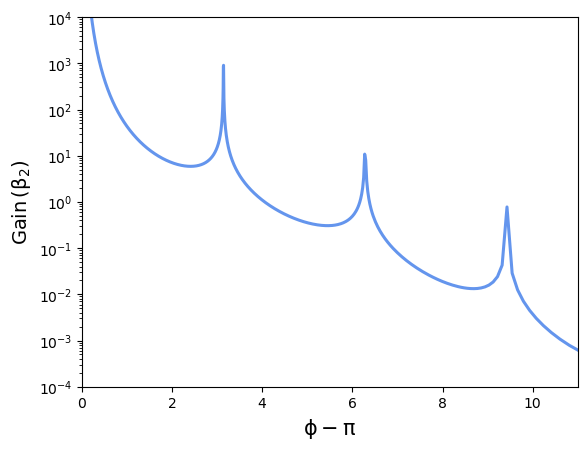

In [37]:
from matplotlib.font_manager import FontProperties
font = FontProperties(family='serif', style='normal')
#plt.rcParams["font.family"] = "sans-serif"

plt.semilogy(phitest-np.pi,gaintest, color='cornflowerblue',linewidth=2.2)
plt.xlim(0,11)
plt.ylim(1e-4,1e4)
plt.xlabel(r'$\rm \phi - \pi$',fontsize=15)
plt.ylabel(r'$\rm Gain \, (\beta_2)$',fontsize=14,fontproperties=font)
# semilogy(ϕ.-π,gain.(β_2))
# axis([0,11,1e-4,1e4])
plt.savefig('phigaintest.png')

In [1]:
import kepler

## scratch paper - don't look!

In [76]:
(u.arcsecond).to(u.rad)

4.84813681109536e-06

In [77]:
#np.log(216*(7-4*np.sqrt(3))) - np.pi

In [ ]:
#const.G
#const.M_sun
#const.c

In [78]:
#dol distance from object to lens
#((2*(const.G)*(1e6*const.M_sun)))/((const.c)**2)
M_bhmw = (2.8e6*u.M_sun).to(u.kg) #mass of MW BH from Msun to kg
#M_bhmw
dol/(((2*(const.G)*(M_bhmw)))/((const.c)**2))
#(((const.c)**2)/(2*(const.G)*(1e6*const.M_sun)))
#asec2rad(16.87e-6)

<Quantity 3.17183959e+10>

In [ ]:
#######
es = collect(0:0.02:1) #range of eccentricities #start, step, stop # step 0.02 is like 51 length
ms = collect(0:0.125:2*π) #mean anomalies #51 length

Earr = zeros(length(ms),length(es))

for i=1:length(ms)
    for j=1:length(es)
        Earr[i,j] = newt_solver(es[j],ms[i]) # solving for eccentric anomaly over a range of values
        #println(ms[i] - Earr[i,j] + es[j]*sin(Earr[i,j])) #to check it's working right :)
    end
end

#calculate for gaiaBH1 as test
ecc1 = orbit1.ecc.val
period1 = orbit1.period.val #period
tp1 = orbit1.tp.val #time of periastron
ts1 = collect(0:1e-1:period1) #array of times from 0 to 3 times the period
MA1 = (2*π/period1)*(ts1.-tp1)  #Mean Anomaly
EccAn1 = newt_solver.(ecc1,MA1); #eccentric anomaly

#function to calculate true anomaly
f(ecc1,EccAn1) = 2*(atan(((1+ecc1/1-ecc1)^0.5)*(tan(EccAn1/2)))) #true anomaly
    f_arr1 = f.(ecc1,EccAn1);

#make function to calculate r = [x,y,z] of new ellipse (aka r_{bh,star})
r1(a,ecc,EccAn) = a*(1 - ecc*cos(EccAn))

a1 = orbit1.a.val
r1_arr = r1.(a1,ecc1,EccAn1);

########

xyz_1 = zeros(3,length(ts1))
function xyzmatrix(r,Ω,ω,f,inc)
    x = r*(cos(Ω)*cos(ω+f) - sin(Ω)*sin(ω+f)*cos(inc))
    y = r*(sin(Ω)*cos(ω+f) + cos(Ω)*sin(ω+f)*cos(inc))
    z = r*(sin(ω+f)*sin(inc))
    return [x,y,z]
end

Ω1 = (orbit1.Omega.val)*(π/180)
ω1 = orbit1.omega.val*(π/180)
inc1 = orbit1.incl.val*(π/180)

for i=1:length(f_arr1)
    xyz_1[:,i] = xyzmatrix(r1_arr[i],Ω1,ω1,f_arr1[i],inc1)
end

##########
x1=xyz_1[1,:]
y1=xyz_1[2,:]
z1=xyz_1[3,:]

function getalpha(x,y,z)
    alpha = acos((-z)/sqrt(x^2+y^2+z^2))
    return alpha
end

alpha1 = getalpha.(x1,y1,z1);

#########
gainα1 = interBeta2Ngain.(alpha1);